# **House Price Prediction Model**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Polynomial
features
from sklearn.metrics import r2_score

In [ ]:
file_path = "train (1).csv"

In [ ]:
data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "rishitaverma02/house-prices-advanced-regression-techniques",
  file_path,)

Using Colab cache for faster access to the 'house-prices-advanced-regression-techniques' dataset.


### **Filtering Out the Data**

In [ ]:
print(data.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
print(data.describe())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.066207   456.098091  ..

### keep numeric columns only

In [ ]:
data = data.select_dtypes(include=[np.number])
data = data.fillna(data.mean())

### **Heatmap Visualization**

In [ ]:
corr = data.corr()

In [ ]:
top_features = corr["SalePrice"].abs().sort_values(ascending=False).head(10).index

In [ ]:
top_corr = data[top_features].corr()

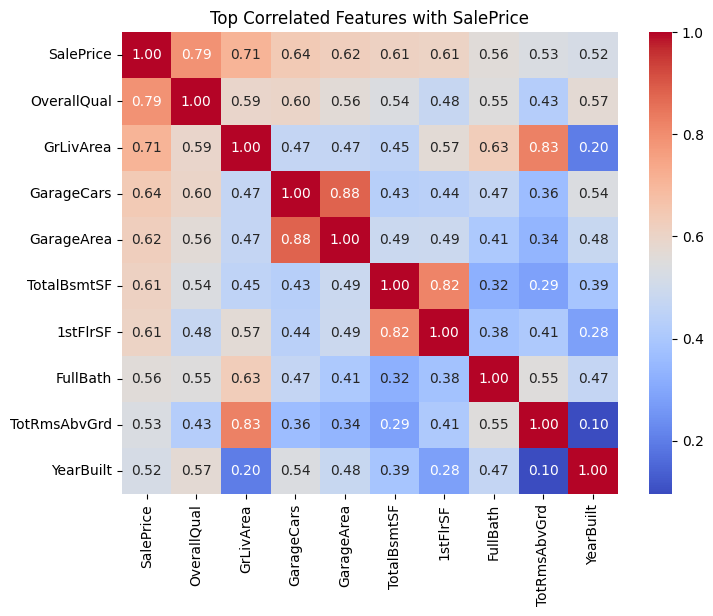

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(top_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top Correlated Features with SalePrice")
plt.show()

### **Scatter Plot Visualization**

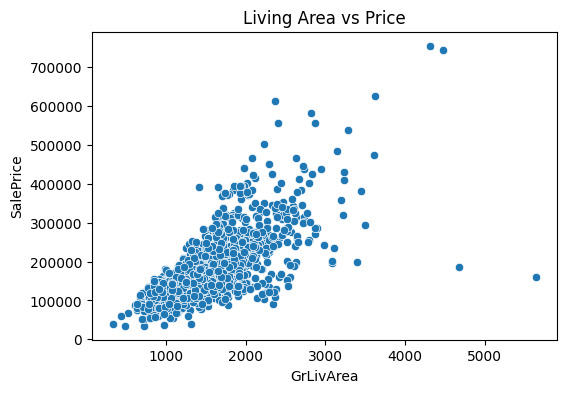

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=data["GrLivArea"], y=data["SalePrice"])
plt.title("Living Area vs Price")
plt.show()

### **Histplot Visualization**

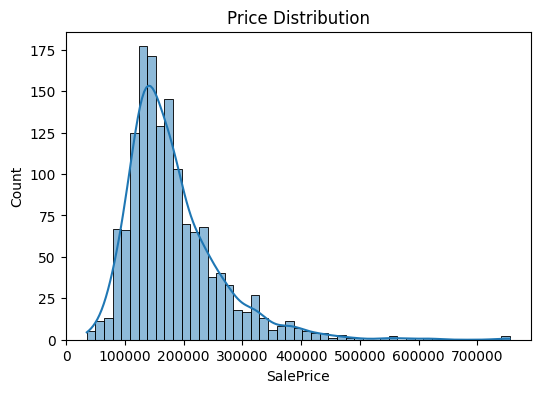

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(data["SalePrice"], kde=True)
plt.title("Price Distribution")
plt.show()

### **Training & Testing the Model**

In [ ]:
X = data.drop("SalePrice", axis=1)
y = data["SalePrice"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

### **Random Forest**

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

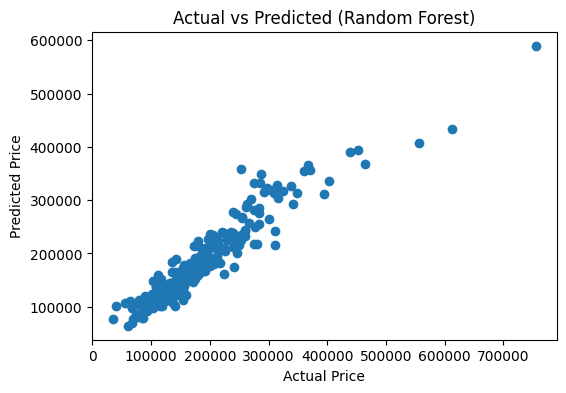

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

### **Linear & Random Forest**

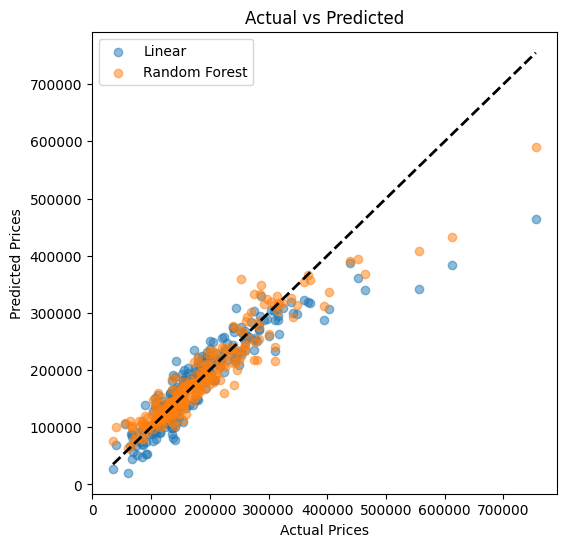

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_pred, alpha=0.5, label="Linear")
plt.scatter(y_test, rf_pred, alpha=0.5, label="Random Forest")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', lw=2)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

### **Polynomial Regression**

In [ ]:
feature = "GrLivArea"

In [ ]:
X = data[[feature]].values
y = data["SalePrice"].values

In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [ ]:
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [ ]:
sorted_idx = X[:, 0].argsort()
X_sorted = X[sorted_idx]

In [ ]:
y_poly = model.predict(poly.transform(X_sorted))

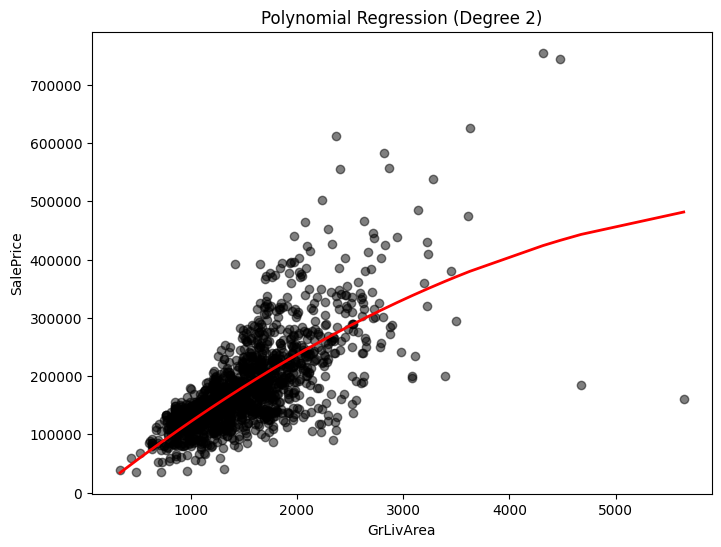

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='black', alpha=0.5)
plt.plot(X_sorted, y_poly, color='red', linewidth=2)
plt.xlabel(feature)
plt.ylabel("SalePrice")
plt.title("Polynomial Regression (Degree 2)")
plt.show()

### **Linear v/s Polynomial**

In [ ]:
X_vis = data[[feature]].values
y_vis = data["SalePrice"].values

In [ ]:
lr_vis = LinearRegression()
lr_vis.fit(X_vis, y_vis)

LinearRegression()

In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_vis)

In [ ]:
poly_model = LinearRegression()
poly_model.fit(X_poly, y_vis)

LinearRegression()

In [ ]:
sorted_idx = X_vis[:, 0].argsort()
X_sorted = X_vis[sorted_idx]

In [ ]:
y_lr_line = lr_vis.predict(X_sorted)
y_poly_curve = poly_model.predict(poly.transform(X_sorted))

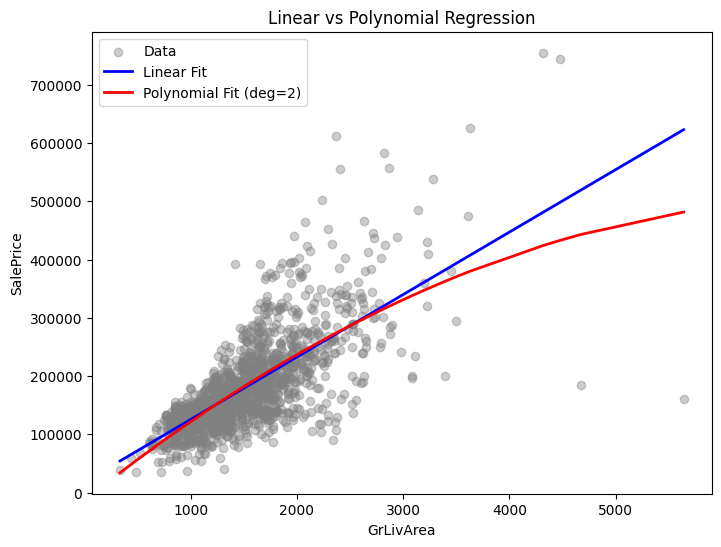

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_vis, y_vis, color='gray', alpha=0.4, label="Data")

plt.plot(X_sorted, y_lr_line, color='blue', linewidth=2, label="Linear Fit")
plt.plot(X_sorted, y_poly_curve, color='red', linewidth=2, label="Polynomial Fit (deg=2)")

plt.xlabel(feature)
plt.ylabel("SalePrice")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

### **R2 Score**

In [ ]:
print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression R2: 0.8227439852048932


In [ ]:
print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest R2: 0.8876608936789179


In [ ]:
print("Polynomial Regression R2:", r2_score(y_test, poly_test_pred))

Polynomial Regression R2: 0.5332176350273322
